<a href="https://colab.research.google.com/github/luqmantalha/Mechine-Learning-Lab-/blob/main/ML_Lab_7%268.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/boston.csv')

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
df.columns


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
x = df.drop('MEDV',axis=1)
y  = df['MEDV']

In [ ]:
import numpy as np
x = np.array(x)
y = np.array(y).reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [ ]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 7)
Ridge_cv = RidgeCV(alphas=alphas, cv=10)
Ridge_cv.fit(x_train, y_train)
print("Best Alpha:",Ridge_cv.alpha_)

Best Alpha: 10.0


In [ ]:
from sklearn.linear_model import Ridge
best_ridge = Ridge(alpha=Ridge_cv.alpha_)
best_ridge.fit(x_train, y_train)

y_pred = best_ridge.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
mse = mean_squared_error(y_test, y_pred)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
#MSE
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
#RMSE
rmse=np.sqrt(mse)
print("RMSE:", rmse)
#R2 Score
r2 = r2_score(y_test,y_pred)
print("R^2 score:", r2)

MSE: 24.4958456196674
RMSE: 4.949327794728028
R^2 score: 0.6659677905050341


Text(0, 0.5, 'Predicted Values')

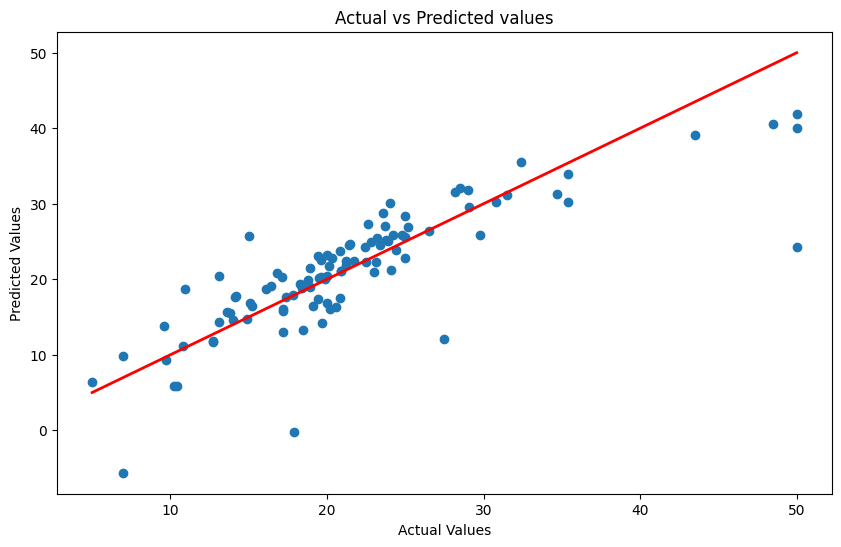

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'r-', lw=2)
plt.title("Actual vs Predicted values")
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
from sklearn.linear_model import LassoCV
#Try multiple alpha values
alphas=np.logspace (-3,3,7)
lasso_cv=LassoCV(alphas=alphas, cv = 10 )
lasso_cv.fit(x_train, y_train)
print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.01


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
best_lasso = Lasso(alpha=lasso_cv.alpha_)
best_lasso.fit(x_train, y_train)

Lasso(alpha=np.float64(0.01))

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
#MSE
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)
#RMSE
rmse=np.sqrt(mse)
print("RMSE:", rmse)
#R2 Score
r2=r2_score(y_test,y_pred)
print("R^2 score:", r2)

MSE: 24.4958456196674
RMSE: 4.949327794728028
R^2 score: 0.6659677905050341


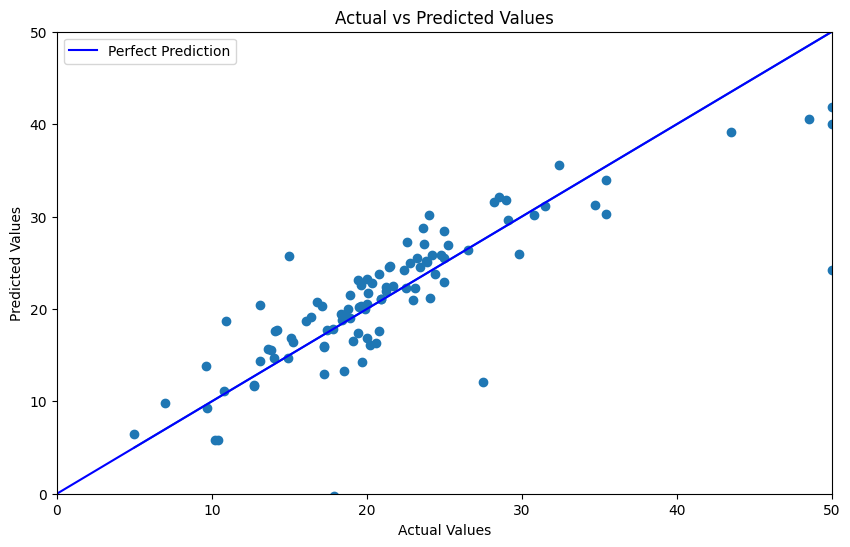

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
max_val = max(np.max(y_test), np.max(y_pred))
plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.plot([0, max_val], [0, max_val], 'b', label='Perfect Prediction')
plt.legend()
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()